In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PowerTransformer, OneHotEncoder

# Loading the Dataset

In [28]:
df_a = pd.read_excel('PCOS_data_without_infertility_tailored.xlsx', sheet_name = 'Full_new')
print("Initial shape:", df_a.shape)
df_a.head()

Initial shape: (536, 45)


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Column1
0,1,1,0,28,44.6,152.0,19.3,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,NaN,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,NaN,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,NaN,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,NaN,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


# Data Cleaning, Checking for Duplicates, Missing Values and Clearly Irrelevant Columns

In [29]:
n_duplicates = df_a.duplicated().sum()
print(f"Found {n_duplicates} duplicate rows.")

Found 0 duplicate rows.


In [30]:
print("\nMissing values per column:")
print(df_a.isnull().sum())


Missing values per column:
Sl. No                      0
Patient File No.            0
PCOS (Y/N)                  0
 Age (yrs)                  0
Weight (Kg)                 0
Height(Cm)                  0
BMI                       294
Blood Group                 0
Pulse rate(bpm)             0
RR (breaths/min)            0
Hb(g/dl)                    0
Cycle(R/I)                  0
Cycle length(days)          0
Marraige Status (Yrs)       1
Pregnant(Y/N)               0
No. of aborptions           0
  I   beta-HCG(mIU/mL)      0
II    beta-HCG(mIU/mL)      0
FSH(mIU/mL)                 0
LH(mIU/mL)                  0
FSH/LH                    527
Hip(inch)                   0
Waist(inch)                 0
Waist:Hip Ratio           527
TSH (mIU/L)                 0
AMH(ng/mL)                  0
PRL(ng/mL)                  0
Vit D3 (ng/mL)              0
PRG(ng/mL)                  0
RBS(mg/dl)                  0
Weight gain(Y/N)            0
hair growth(Y/N)            0
Skin darkeni

In [31]:
df_b = df_a.drop(['Sl. No', 'Patient File No.', 'Column1'], axis = 1)

In [32]:
# Create a list of new column names (must match the number of columns in df)
new_column_names = [
    'PCOS_Diagnosis', 'Age', 'Weight', 'Height', 'Body_Mass_Index', 'Blood_Type', 'Pulse_Rate', 'Respiratory_Rate',
    'Hemoglobin', 'Cycle_Regularity', 'Cycle_Length', 'Marriage_History', 'Pregnant', 'Abortions', 'Beta_HCG_1',
    'Beta_HCG_2', 'FSH', 'LH', 'FSH_LH_Ratio', 'Hip', 'Waist', 'Waist_Hip_Ratio', 'TSH', 'AMH', 'Prolactin',
    'Vitamin_D3', 'Progesterone', 'Random_Blood_Sugar', 'Weight_Gain', 'Hair_Growth', 'Skin_Darkening', 'Hair_Loss',
    'Pimples', 'Fast_Food', 'Regular_Exercise', 'BP_Systolic', 'BP_Diastolic', 'Follicle_Count_Left',
    'Follicle_Count_Right', 'Avg_Follicle_Size_Left', 'Avg_Follicle_Size_Right', 'Endometrium_Thickness'
]

# Assign the new column names
df_b.columns = new_column_names

# Preview the updated DataFrame
print(df_b.head())

   PCOS_Diagnosis  Age  Weight  Height  Body_Mass_Index  Blood_Type  \
0               0   28    44.6   152.0             19.3          15   
1               0   36    65.0   161.5              NaN          15   
2               1   33    68.8   165.0              NaN          11   
3               0   37    65.0   148.0              NaN          13   
4               0   25    52.0   161.0              NaN          11   

   Pulse_Rate  Respiratory_Rate  Hemoglobin  Cycle_Regularity  ...  Pimples  \
0          78                22       10.48                 2  ...        0   
1          74                20       11.70                 2  ...        0   
2          72                18       11.80                 2  ...        1   
3          72                20       12.00                 2  ...        0   
4          72                18       10.00                 2  ...        0   

   Fast_Food  Regular_Exercise  BP_Systolic  BP_Diastolic Follicle_Count_Left  \
0        1.0     

In [33]:
df_b.dtypes

PCOS_Diagnosis               int64
Age                          int64
Weight                     float64
Height                     float64
Body_Mass_Index            float64
Blood_Type                   int64
Pulse_Rate                   int64
Respiratory_Rate             int64
Hemoglobin                 float64
Cycle_Regularity             int64
Cycle_Length                 int64
Marriage_History           float64
Pregnant                     int64
Abortions                    int64
Beta_HCG_1                 float64
Beta_HCG_2                  object
FSH                        float64
LH                         float64
FSH_LH_Ratio               float64
Hip                          int64
Waist                        int64
Waist_Hip_Ratio            float64
TSH                        float64
AMH                         object
Prolactin                  float64
Vitamin_D3                 float64
Progesterone               float64
Random_Blood_Sugar         float64
Weight_Gain         

# Data Cleaning, Checking for Inconsistencies

In [34]:
df_c = df_b

In [35]:
non_numeric = df_c['Beta_HCG_2'][pd.to_numeric(df_c['Beta_HCG_2'], errors='coerce').isna()]
unique_non_numeric = non_numeric.unique()
print(unique_non_numeric)

['1.99.']


In [36]:
df_c['Beta_HCG_2'] = df_c['Beta_HCG_2'].replace('1.99.', '1.99')
df_c['Beta_HCG_2'] = pd.to_numeric(df_c['Beta_HCG_2'], errors='coerce')

In [37]:
non_numeric = df_c['AMH'][pd.to_numeric(df_c['AMH'], errors='coerce').isna()]
unique_non_numeric = non_numeric.unique()
print(unique_non_numeric)

['a']


In [38]:
df_c['AMH'] = df_c['AMH'].replace('a', np.nan)
df_c['AMH'] = pd.to_numeric(df_c['AMH'], errors='coerce')

/var/folders/st/gjzvx4bd6tb2rmgsn90n5pwm0000gp/T/ipykernel_32450/1556391756.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_c['AMH'] = df_c['AMH'].replace('a', np.nan)


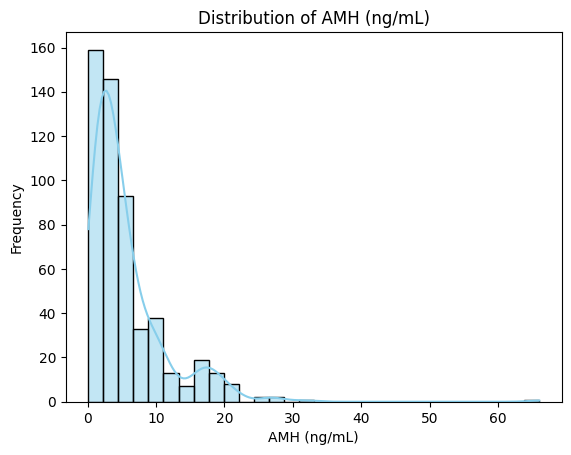

In [39]:
# Drop missing values for visualization
sns.histplot(df_c['AMH'].dropna(), kde=True, bins=30, color='skyblue')
plt.title('Distribution of AMH (ng/mL)')
plt.xlabel('AMH (ng/mL)')
plt.ylabel('Frequency')
plt.show()


In [40]:
df_c['AMH'].fillna(df_c['AMH'].median(), inplace=True)

/var/folders/st/gjzvx4bd6tb2rmgsn90n5pwm0000gp/T/ipykernel_32450/4089682411.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_c['AMH'].fillna(df_c['AMH'].median(), inplace=True)


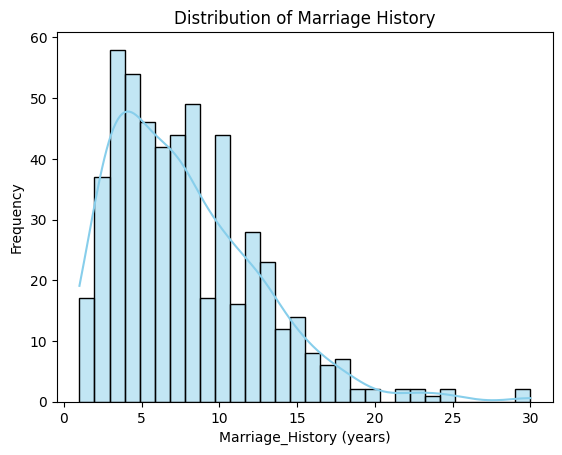

In [41]:
# Drop missing values for visualization
sns.histplot(df_c['Marriage_History'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Marriage History')
plt.xlabel('Marriage_History (years)')
plt.ylabel('Frequency')
plt.show()

In [42]:
df_c['Marriage_History'].fillna(df_c['Marriage_History'].median(), inplace=True)

/var/folders/st/gjzvx4bd6tb2rmgsn90n5pwm0000gp/T/ipykernel_32450/2573067723.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_c['Marriage_History'].fillna(df_c['Marriage_History'].median(), inplace=True)


In [43]:
df_c['Fast_Food'].fillna(df_c['Fast_Food'].mode()[0], inplace=True)

/var/folders/st/gjzvx4bd6tb2rmgsn90n5pwm0000gp/T/ipykernel_32450/2428899586.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_c['Fast_Food'].fillna(df_c['Fast_Food'].mode()[0], inplace=True)


In [44]:
df_c['Cycle_Regularity'].unique()

array([2, 4, 5])

In [45]:
df_c['Cycle_Regularity'].value_counts()

Cycle_Regularity
2    386
4    149
5      1
Name: count, dtype: int64

In [46]:
df_c['Cycle_Regularity'].replace(5, df_c['Cycle_Regularity'].mode()[0], inplace=True)

/var/folders/st/gjzvx4bd6tb2rmgsn90n5pwm0000gp/T/ipykernel_32450/1978156457.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_c['Cycle_Regularity'].replace(5, df_c['Cycle_Regularity'].mode()[0], inplace=True)


In [47]:
print("\nMissing values per column:")
print(df_c.isnull().sum())


Missing values per column:
PCOS_Diagnosis               0
Age                          0
Weight                       0
Height                       0
Body_Mass_Index            294
Blood_Type                   0
Pulse_Rate                   0
Respiratory_Rate             0
Hemoglobin                   0
Cycle_Regularity             0
Cycle_Length                 0
Marriage_History             0
Pregnant                     0
Abortions                    0
Beta_HCG_1                   0
Beta_HCG_2                   0
FSH                          0
LH                           0
FSH_LH_Ratio               527
Hip                          0
Waist                        0
Waist_Hip_Ratio            527
TSH                          0
AMH                          0
Prolactin                    0
Vitamin_D3                   0
Progesterone                 0
Random_Blood_Sugar           0
Weight_Gain                  0
Hair_Growth                  0
Skin_Darkening               0
Hair_Loss  

# Data Cleaning/Aggregation

In [48]:
df_d = df_c

In [49]:
df_d['Body_Mass_Index'] = df_d['Weight'] / df_d['Height'] ** 2 * 10000
df_d['FSH_LH_Ratio'] = df_d['FSH'] / df_d['LH']
df_d['Waist_Hip_Ratio'] = df_d['Waist'] / df_d['Hip']

In [50]:
print("\nMissing values per column:")
print(df_d.isnull().sum())



Missing values per column:
PCOS_Diagnosis             0
Age                        0
Weight                     0
Height                     0
Body_Mass_Index            0
Blood_Type                 0
Pulse_Rate                 0
Respiratory_Rate           0
Hemoglobin                 0
Cycle_Regularity           0
Cycle_Length               0
Marriage_History           0
Pregnant                   0
Abortions                  0
Beta_HCG_1                 0
Beta_HCG_2                 0
FSH                        0
LH                         0
FSH_LH_Ratio               0
Hip                        0
Waist                      0
Waist_Hip_Ratio            0
TSH                        0
AMH                        0
Prolactin                  0
Vitamin_D3                 0
Progesterone               0
Random_Blood_Sugar         0
Weight_Gain                0
Hair_Growth                0
Skin_Darkening             0
Hair_Loss                  0
Pimples                    0
Fast_Food      

In [52]:
X_train, X_test, y_train, y_test = train_test_split(df_d.drop('PCOS_Diagnosis', axis=1), df_d['PCOS_Diagnosis'], test_size=0.2, random_state=42)


In [56]:
log_model = LogisticRegression(max_iter=1000)


In [57]:
y_train


347    1
440    1
421    0
149    1
192    0
      ..
71     0
106    1
270    0
435    0
102    0
Name: PCOS_Diagnosis, Length: 428, dtype: int64